In [2]:
import sys
import os
import numpy as np

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('..'))
from src.store import DataStore
from src.vector_backtester import PortfolioVectorEngine

# 2. Load Data
print("🗄️ Initializing Librarian...")
store = DataStore(library_name="fx.min")
target_asset = 'C:EURUSD'

# Pulling 3 months of 1-minute bars
df = store.load(target_asset, start_date="2023-10-01", end_date="2024-01-01")

if df is not None:
    print(f"✅ Loaded {len(df):,} rows of {target_asset}.")
    
    # ==========================================
    # 🧠 3. THE LAB: SMA Crossover Logic
    # ==========================================
    # Parameters (in minutes)
    fast_window = 60   # 1 Hour
    slow_window = 240  # 4 Hours
    
    # Calculate Indicators
    df['sma_fast'] = df['close'].rolling(window=fast_window).mean()
    df['sma_slow'] = df['close'].rolling(window=slow_window).mean()
    
    # Initialize position target (0 = Flat)
    df['signal'] = 0.0 
    
    # The Rules
    df.loc[df['sma_fast'] > df['sma_slow'], 'signal'] = 1.0  # Golden Cross -> Long
    df.loc[df['sma_fast'] < df['sma_slow'], 'signal'] = -1.0 # Death Cross -> Short
    
    # Forward fill handles any NaNs during the initial rolling windows
    df['signal'] = df['signal'].replace(0.0, np.nan).ffill().fillna(0.0)
    
    # ==========================================
    # 📊 4. THE EVALUATION
    # ==========================================
    print("⚙️ Igniting Vector Engine...")
    
    # We pass the raw close prices and our target signals
    engine = VectorEngine(
        prices=df['close'], 
        signals=df['signal'], 
        tc_bps=0.2,        # 0.2 bps spread assumption for EUR/USD
        execution_delay=1  # Wait 1 bar to execute to prevent look-ahead bias
    )
    
    engine.run()
    engine.tearsheet(title=f"SMA Crossover ({fast_window}m / {slow_window}m)")

else:
    print(f"❌ Could not load data for {target_asset}.")

🗄️ Initializing Librarian...
✅ Loaded 5 rows of C:EURUSD.


AttributeError: 'dict' object has no attribute 'loc'

🚀 Igniting Grid Optimizer: Testing 16 combinations...
   [10/16] combinations tested...
✅ Optimization Complete.

🏆 Top 5 Parameter Combinations:


,fast_window,slow_window,Total_Return_%,Sharpe,Max_DD_%,Trades
0,60,240,-2.676147,-1.233237,-4.094338,506
1,60,300,-3.802964,-1.780700,-5.785385,438
2,30,300,-6.203149,-2.968177,-7.275419,594
3,30,240,-6.370521,-3.051663,-7.353317,708
4,15,300,-7.798531,-3.773857,-9.269295,862


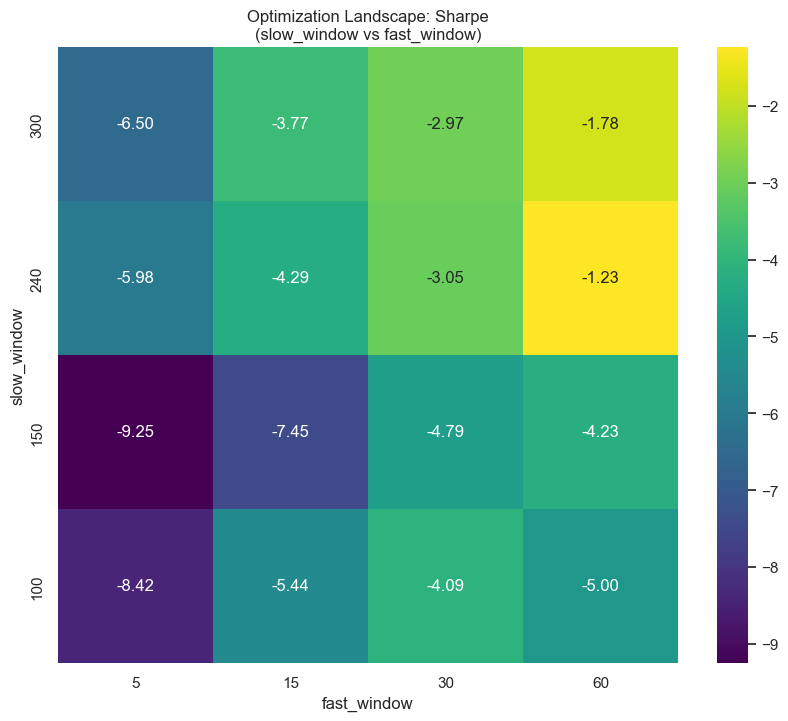

In [3]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))
from src.store import DataStore
from src.optimizer import GridOptimizer

# 1. Load Data
store = DataStore(library_name="fx.min")
df = store.load('C:EURUSD', start_date="2023-10-01", end_date="2024-01-01")

# ==========================================
# 🧠 2. DEFINE THE STRATEGY LOGIC
# The Optimizer will feed parameters into this function
# ==========================================
def sma_crossover_logic(data, fast_window, slow_window):
    # This function MUST return a pandas Series of signals (-1.0, 0.0, 1.0)
    data['fast'] = data['close'].rolling(fast_window).mean()
    data['slow'] = data['close'].rolling(slow_window).mean()
    
    data['signal'] = 0.0
    data.loc[data['fast'] > data['slow'], 'signal'] = 1.0
    data.loc[data['fast'] < data['slow'], 'signal'] = -1.0
    
    return data['signal'].replace(0.0, np.nan).ffill().fillna(0.0)

# ==========================================
# ⚙️ 3. DEFINE THE GRID & RUN
# ==========================================
# We want to test Fast SMAs from 5 to 60, and Slow SMAs from 100 to 300
param_grid = {
    'fast_window': [5, 15, 30, 60],
    'slow_window': [100, 150, 240, 300]
}

# Initialize and run (4 * 4 = 16 combinations)
optimizer = GridOptimizer(
    prices_df=df,
    target_col='close',
    signal_func=sma_crossover_logic,
    param_grid=param_grid,
    tc_bps=0.2
)

# Run the optimization
best_params_df = optimizer.run(parallel=False) 

# Display the Top 5 results
print("\n🏆 Top 5 Parameter Combinations:")
display(best_params_df.head())

# Plot the Landscape
optimizer.plot_heatmap(x_param='fast_window', y_param='slow_window', metric='Sharpe')